In [2]:
import openmc.deplete
import matplotlib.pyplot as plt
import numpy as np

PATH = "depletion_pitch_1_000"
#giorni_on = [0.1, 0.4, 0.5, 1.0, 3.0, 5.0, 10.0 , 30.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0]
#giorni_off = [0.05, 0.1, 0.15, 0.2, 0.5, 1.0, 3.0, 3,3,3,3,10.0, 15.0, 20.0]

giorni_on= [0.5, 0.5, 4.0, 5.0, 10.0 ,30.0, 300, 50.0]
giorni_off = [0.05, 0.1, 0.15, 0.2, 0.5, 1.0, 3.0, 3 , 25, 20.0] 

#giorni_on = [0.1, 0.4, 0.5, 4, 5.0, 10.0,30.0, 300, 50.0]
#giorni_off = [0.05, 0.25 , 0.2, 1.5, 6, 45] 

#giorni_on = [0.5, 0.5, 4, 5.0, 10.0, 30.0, 50 , 50, 50,50, 50 ,50, 50.0]
#giorni_off = [0.05, 0.1 , 0.15 , 0.2, 0.5, 1, 3 , 3 ,3 ,3, 3 , 15, 20] 

spegnimento  = sum(giorni_on)

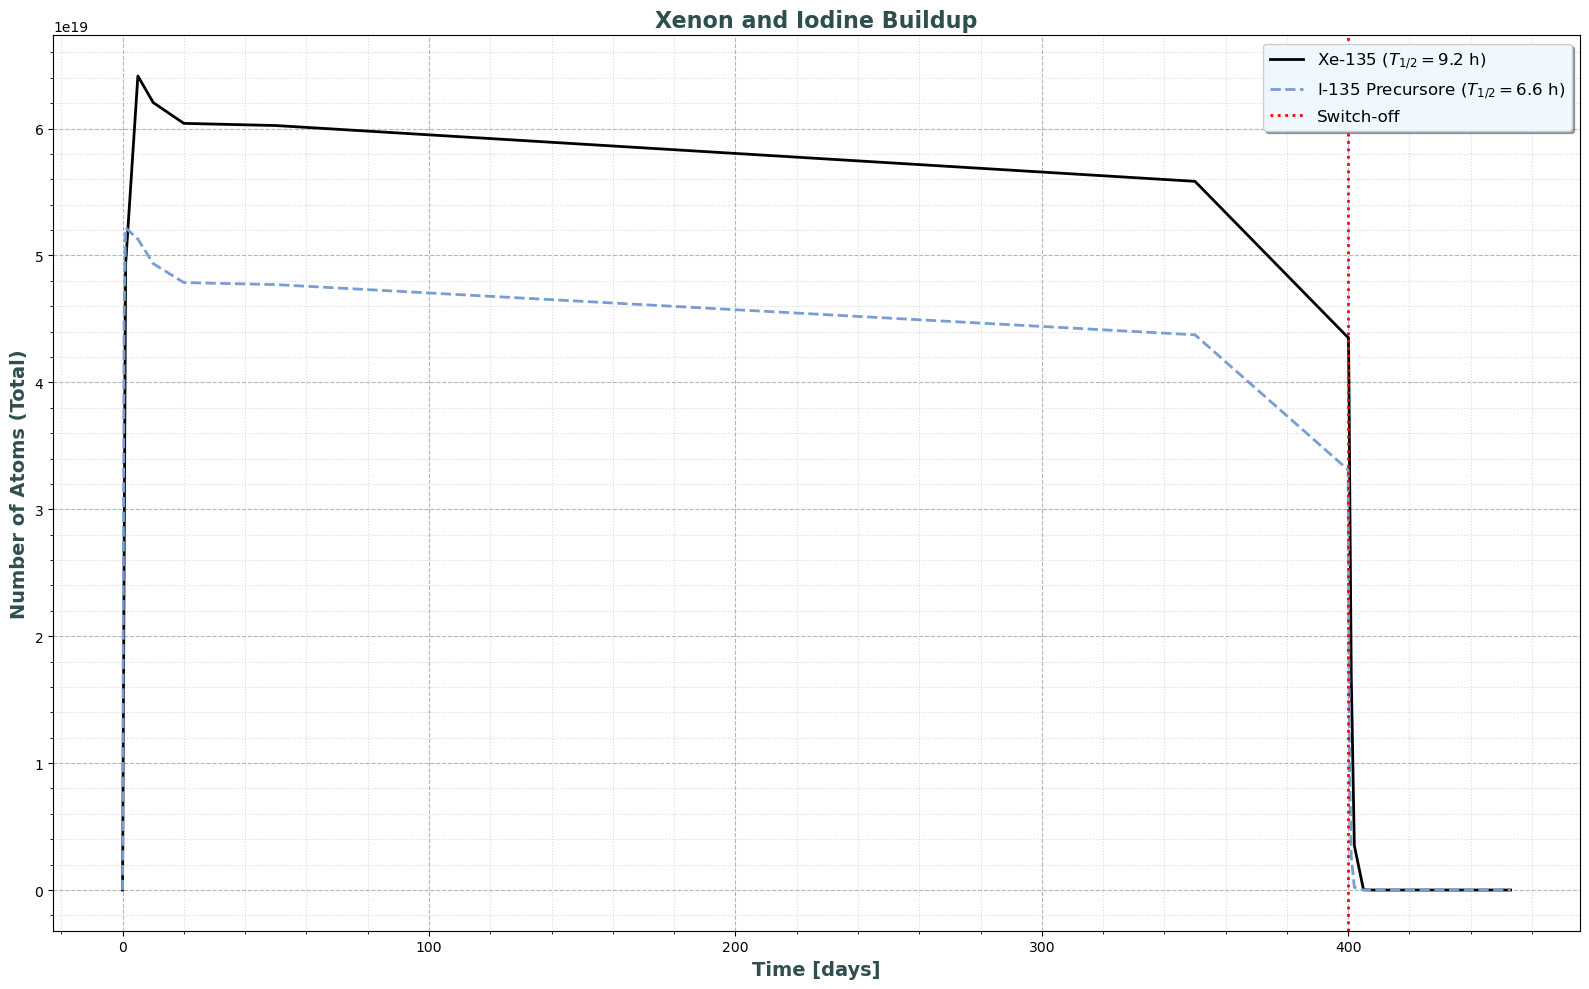

In [3]:

# 1. Caricamento dei risultati dal file HDF5
results = openmc.deplete.Results(f"{PATH}/depletion_results.h5")

# 2. Estrazione vettori temporali
time_sec, _ = results.get_keff()
days = time_sec / (24 * 3600)

# Inizializzazione array per la somma globale
xenon_tot = np.zeros_like(days)
iodine_tot = np.zeros_like(days)

# 3. Estrazione dinamica degli ID materiali
depletable_mat_ids = list(results[0].volume.keys())

# Iterazione su tutti i materiali per ottenere l'inventario globale
for mat_id in depletable_mat_ids:
    _, xe_atoms = results.get_atoms(mat_id, "Xe135")
    _, i_atoms = results.get_atoms(mat_id, "I135")
    
    xenon_tot += xe_atoms
    iodine_tot += i_atoms
    

# 4. Plotting in stile scientifico (Unificato con lo stile richiesto)
fig, ax = plt.subplots(figsize=(16, 10))

# FIX: Adesso usiamo i vettori "_clean" per saltare lo spike!
ax.plot(days, xenon_tot, label=r"Xe-135 ($T_{1/2} = 9.2$ h)", color='#000000', linewidth=2)
ax.plot(days, iodine_tot, label=r"I-135 Precursore ($T_{1/2} = 6.6$ h)", color='#789DD1', linestyle='--', linewidth=2)
ax.axvline(x=spegnimento, color='red', linestyle=':', label="Switch-off", linewidth=2)

# Assi e Titolo conforme allo standard
ax.set_title("Xenon and Iodine Buildup", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Time [days]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Number of Atoms (Total)", fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglia conforme allo standard
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda conforme allo standard
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

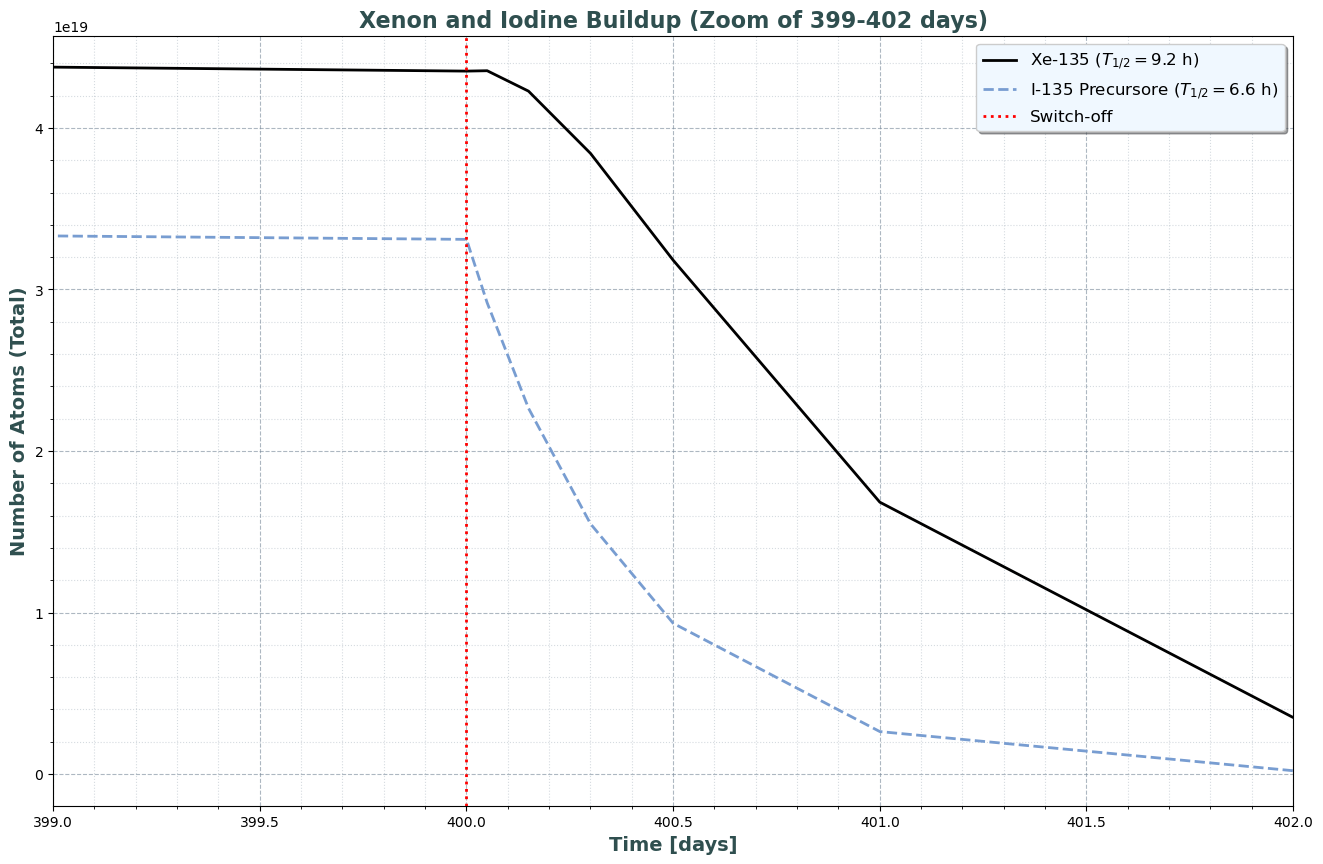

In [4]:
mask = (days >= 399) & (days <= 402)
days_zoom = days[mask]
xenon_zoom = xenon_tot[mask]
iodine_zoom = iodine_tot[mask]

# Calcolo dei limiti ottimali per l'asse Y con un padding del 5%
y_min = min(min(xenon_zoom), min(iodine_zoom))
y_max = max(max(xenon_zoom), max(iodine_zoom))
padding = (y_max - y_min) * 0.05

fig2, ax2 = plt.subplots(figsize=(16, 10))

ax2.plot(days, xenon_tot, label=r"Xe-135 ($T_{1/2} = 9.2$ h)", color='#000000', linewidth=2)
ax2.plot(days, iodine_tot, label=r"I-135 Precursore ($T_{1/2} = 6.6$ h)", color='#789DD1', linestyle='--', linewidth=2)
ax2.axvline(x=spegnimento, color='red', linestyle=':', label="Switch-off", linewidth=2)

# Zoom sui limiti X e Y calcolati
ax2.set_xlim(399, 402)
ax2.set_ylim(y_min - padding, y_max + padding)

# Assi e Titolo
ax2.set_title("Xenon and Iodine Buildup (Zoom of 399-402 days)", fontsize=16, fontweight='bold', color='#2F4F4F')
ax2.set_xlabel("Time [days]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel("Number of Atoms (Total)", fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglia
ax2.minorticks_on()
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax2.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()

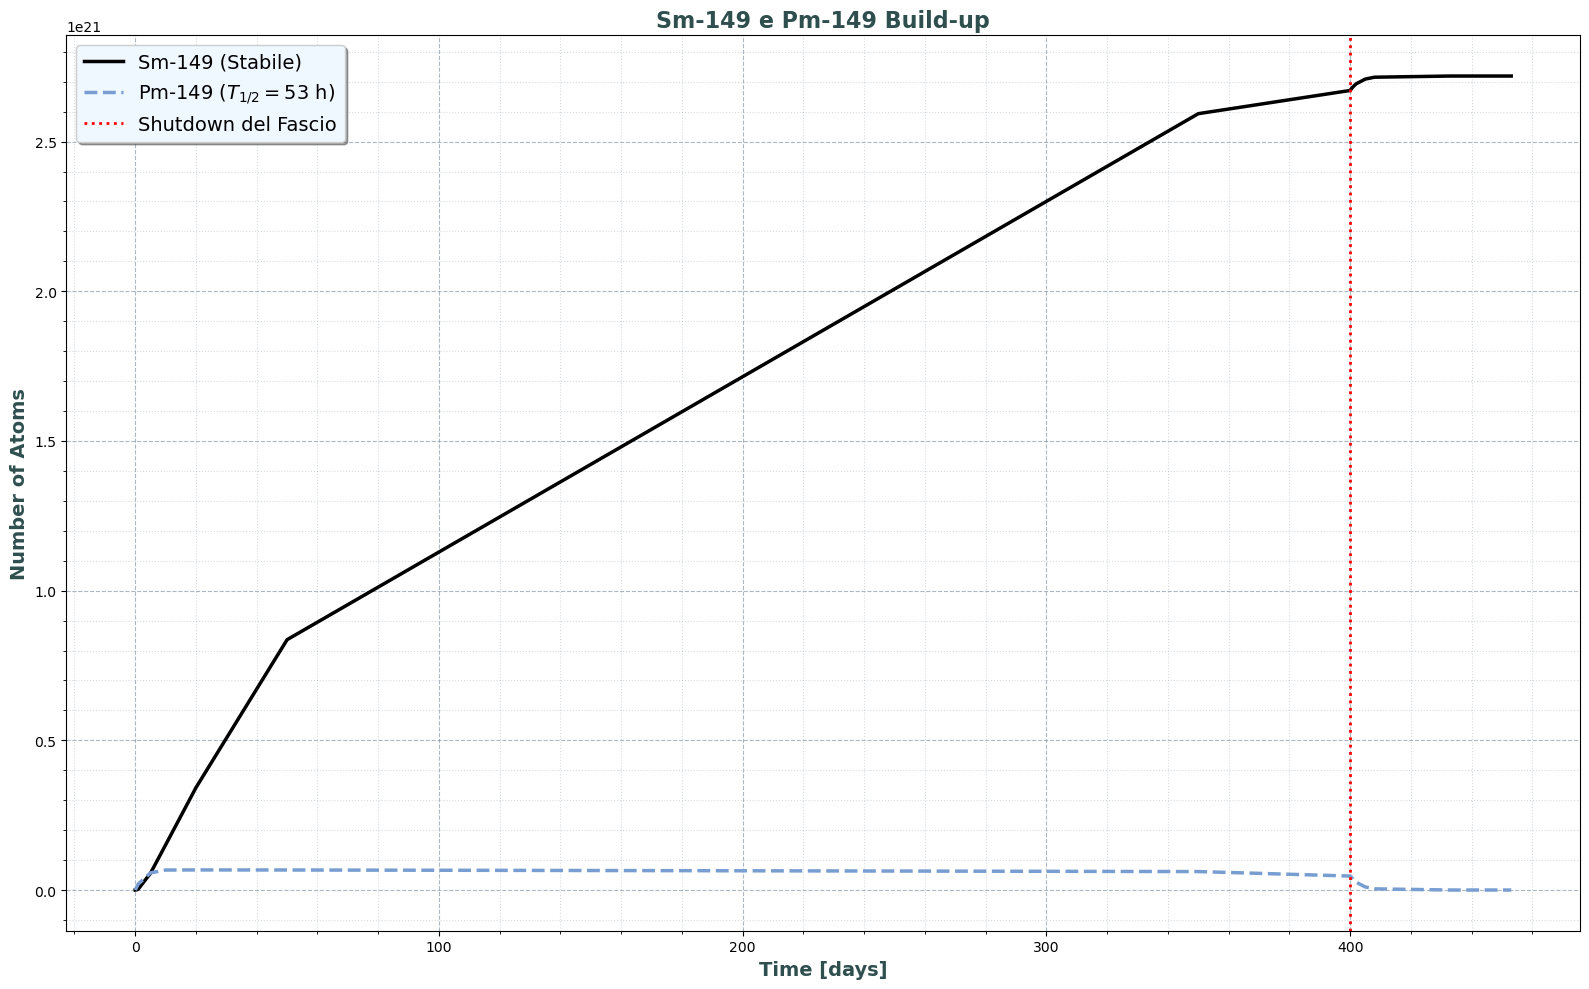

In [5]:
time_sec, _ = results.get_keff()
days = (time_sec / (24 * 3600))

# Inizializzazione array per i veleni sulla base della nuova lunghezza pulita (29 o 30 punti)
samarium_tot = np.zeros_like(days)
promethium_tot = np.zeros_like(days)

# 2. Estrazione dinamica e somma globale filtrando lo spike sul singolo indice
depletable_mat_ids = list(results[0].volume.keys())

for mat_id in depletable_mat_ids:
    try:
        _, sm_atoms = results.get_atoms(mat_id, "Sm149")
        _, pm_atoms = results.get_atoms(mat_id, "Pm149")
                
        samarium_tot += sm_atoms
        promethium_tot += pm_atoms
        
    except (KeyError, ValueError):
        # Salta i materiali strutturali o il target che non contengono questi isotopi
        continue

# 3. Generazione Plot Unificato (Stile Palette e Dimensioni Richieste)
fig, ax = plt.subplots(figsize=(16, 10))

# Curve di evoluzione isotopica perfettamente continue
ax.plot(days, samarium_tot, label="Sm-149 (Stabile)", color='#000000', linewidth=2.5)
ax.plot(days, promethium_tot, label=r"Pm-149 ($T_{1/2} = 53$ h)", color='#789DD1', linestyle='--', linewidth=2.5)

# Marcatore verticale dello spegnimento
ax.axvline(x=spegnimento, color='red', linestyle=':', linewidth=2, label="Shutdown del Fascio")

# Formattazione assi e titoli scientifici
ax.set_title("Sm-149 e Pm-149 Build-up", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Time [days]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Number of Atoms", fontsize=14, fontweight='bold', color='#2F4F4F')

# Configurazione della griglia (Major e Minor ticks)
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Formattazione estetica della legenda
ax.legend(loc='best', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

Modello Dinamico a Reattore SpentoA seguito dello spegnimento, il flusso neutronico è nullo ($\Phi = 0$). I ratei di produzione da fissione e di distruzione per assorbimento neutronico si azzerano. L'evoluzione isotopica è governata esclusivamente dal decadimento radioattivo dello Iodio-135 e dello Xeno-135:

$$\frac{dI(t)}{dt} = -\lambda_I I(t)$$
$$\frac{dX(t)}{dt} = \lambda_I I(t) - \lambda_X X(t)$$

Integrazione delle EquazioniLa prima equazione ha soluzione immediata per la concentrazione di Iodio:$$I(t) = I_0 e^{-\lambda_I t}$$Sostituendo $I(t)$ nel bilancio dello Xeno, si ottiene un'equazione differenziale lineare del primo ordine non omogenea:$$\frac{dX(t)}{dt} + \lambda_X X(t) = \lambda_I I_0 e^{-\lambda_I t}$$Risolviamo moltiplicando per il fattore integrante $e^{\lambda_X t}$:$$\frac{d}{dt} \left( X(t) e^{\lambda_X t} \right) = \lambda_I I_0 e^{(\lambda_X - \lambda_I) t}$$Integrando tra $0$ e $t$ con condizione iniziale $X(0) = X_0$:$$X(t) e^{\lambda_X t} - X_0 = \frac{\lambda_I I_0}{\lambda_X - \lambda_I} \left( e^{(\lambda_X - \lambda_I) t} - 1 \right)$$Riordinando e isolando $X(t)$, otteniamo la legge di evoluzione temporale esatta per lo Xeno:$$X(t) = X_0 e^{-\lambda_X t} + \frac{\lambda_I I_0}{\lambda_I - \lambda_X} \left( e^{-\lambda_X t} - e^{-\lambda_I t} \right)$$Ricerca del Tempo di Picco ($t_{max}$)Per trovare il massimo di avvelenamento, imponiamo la derivata pari a zero:$$\frac{dX(t)}{dt} = 0 \implies \lambda_X X(t) = \lambda_I I(t)$$Sostituendo le espressioni analitiche di $X(t)$ e $I(t)$:$$\lambda_X \left[ X_0 e^{-\lambda_X t} + \frac{\lambda_I I_0}{\lambda_I - \lambda_X} \left( e^{-\lambda_X t} - e^{-\lambda_I t} \right) \right] = \lambda_I I_0 e^{-\lambda_I t}$$Moltiplichiamo per $e^{\lambda_I t}$ in modo da raggruppare i termini esponenziali:$$\lambda_X X_0 e^{(\lambda_I - \lambda_X) t} + \frac{\lambda_X \lambda_I I_0}{\lambda_I - \lambda_X} \left( e^{(\lambda_I - \lambda_X) t} - 1 \right) = \lambda_I I_0$$Mettiamo a fattor comune $e^{(\lambda_I - \lambda_X) t}$:$$e^{(\lambda_I - \lambda_X) t} \left[ \lambda_X X_0 + \frac{\lambda_X \lambda_I I_0}{\lambda_I - \lambda_X} \right] = \lambda_I I_0 + \frac{\lambda_X \lambda_I I_0}{\lambda_I - \lambda_X}$$Semplifichiamo il termine a destra dell'uguaglianza:$$\frac{\lambda_I I_0 (\lambda_I - \lambda_X) + \lambda_X \lambda_I I_0}{\lambda_I - \lambda_X} = \frac{\lambda_I^2 I_0}{\lambda_I - \lambda_X}$$Semplifichiamo il termine tra parentesi quadre a sinistra:$$\frac{\lambda_X X_0 (\lambda_I - \lambda_X) + \lambda_X \lambda_I I_0}{\lambda_I - \lambda_X}$$Uguagliando i rispettivi numeratori:$$e^{(\lambda_I - \lambda_X) t} \left[ \lambda_X X_0 (\lambda_I - \lambda_X) + \lambda_X \lambda_I I_0 \right] = \lambda_I^2 I_0$$Isoliamo l'esponenziale:$$e^{(\lambda_I - \lambda_X) t} = \frac{\lambda_I^2 I_0}{\lambda_X \lambda_I I_0 + \lambda_X (\lambda_I - \lambda_X) X_0}$$Dividendo numeratore e denominatore per il prodotto $\lambda_I \lambda_X I_0$, otteniamo la formulazione esatta isolata:$$e^{(\lambda_I - \lambda_X) t} = \frac{\frac{\lambda_I}{\lambda_X}}{1 + \frac{\lambda_I - \lambda_X}{\lambda_I} \frac{X_0}{I_0}}$$Applicando il logaritmo naturale, il tempo di picco esatto risulta infine:$$t_{max} = \frac{1}{\lambda_I - \lambda_X} \ln \left[ \frac{\lambda_I}{\lambda_X} \left( 1 + \frac{\lambda_I - \lambda_X}{\lambda_I} \frac{X_0}{I_0} \right)^{-1} \right]$$(Nota: La prima forma fornita conteneva un'espansione in serie di Taylor troncata al primo ordine $(1+y)^{-1} \approx 1-y$. Quell'approssimazione è comunemente utilizzata nei testi per flussi pre-spegnimento elevati, in cui il rapporto $\frac{X_0}{I_0}$ è molto piccolo. L'equazione qui derivata ne rappresenta la soluzione analitica rigorosa).

L'assenza visiva del picco macroscopico nel tuo grafico non è un errore, ma la corretta conseguenza fisica del regime operativo del tuo sistema, unita alla discretizzazione temporale della simulazione.Basso Flusso e Regime AsintoticoIl picco dello Xenon è un fenomeno dominante nei reattori ad alto flusso. Durante l'operatività ad alta potenza, il forte flusso neutronico "brucia" lo Xe-135 per cattura prima che possa decadere, deprimendo fortemente la sua concentrazione di saturazione ($X_0$) e accumulando grandi riserve del precursore I-135 ($I_0$).Il tuo sistema opera a potenze termiche molto basse. A regimi di flusso così limitati, la probabilità di assorbimento neutronico dello Xeno è del tutto trascurabile rispetto al suo decadimento naturale. Come si evince dalle ordinate del tuo grafico al momento dello spegnimento a 100 giorni:$X_0 \approx 2.1 \times 10^{20}$ atomi$I_0 \approx 1.6 \times 10^{20}$ atomiAvere $X_0 > I_0$ implica che il reattore opera già quasi all'equilibrio secolare dei decadimenti radioattivi. Valutando il rateo di variazione allo spegnimento tramite l'equazione $\frac{dX}{dt} = \lambda_I I_0 - \lambda_X X_0$, si ottiene un valore iniziale appena sufficiente a superare lo zero. Questo genera un accumulo teorico infinitesimo che raggiunge il suo massimo analitico in meno di mezz'ora, dopodiché il sistema entra in fase di puro decadimento decrescente.Risoluzione Temporale della SimulazioneA livello numerico, la griglia di estrazione dati del tuo plot mostra un passo (distanza tra i marker impliciti) di 0.1 giorni, ovvero 2.4 ore. Anche assumendo la presenza del citato micro-picco nei primissimi minuti post-transitorio, questo cade interamente all'interno del primo intervallo di simulazione. I punti estratti dal codice "saltano" la dinamica rapida, tracciando la linea direttamente verso il valore già decrescente a $t=100.1$.Operativamente questo si traduce in un vantaggio per l'ottimizzazione del reattore sottocritico: non avendo l'avvelenamento transitorio profondo dello Xe-135, non hai i classici "tempi morti" prolungati (dead time) che impediscono il riavvio del reattore nelle ore immediatamente successive allo spegnimento.

ALLA RICERCA DEI PICCHI

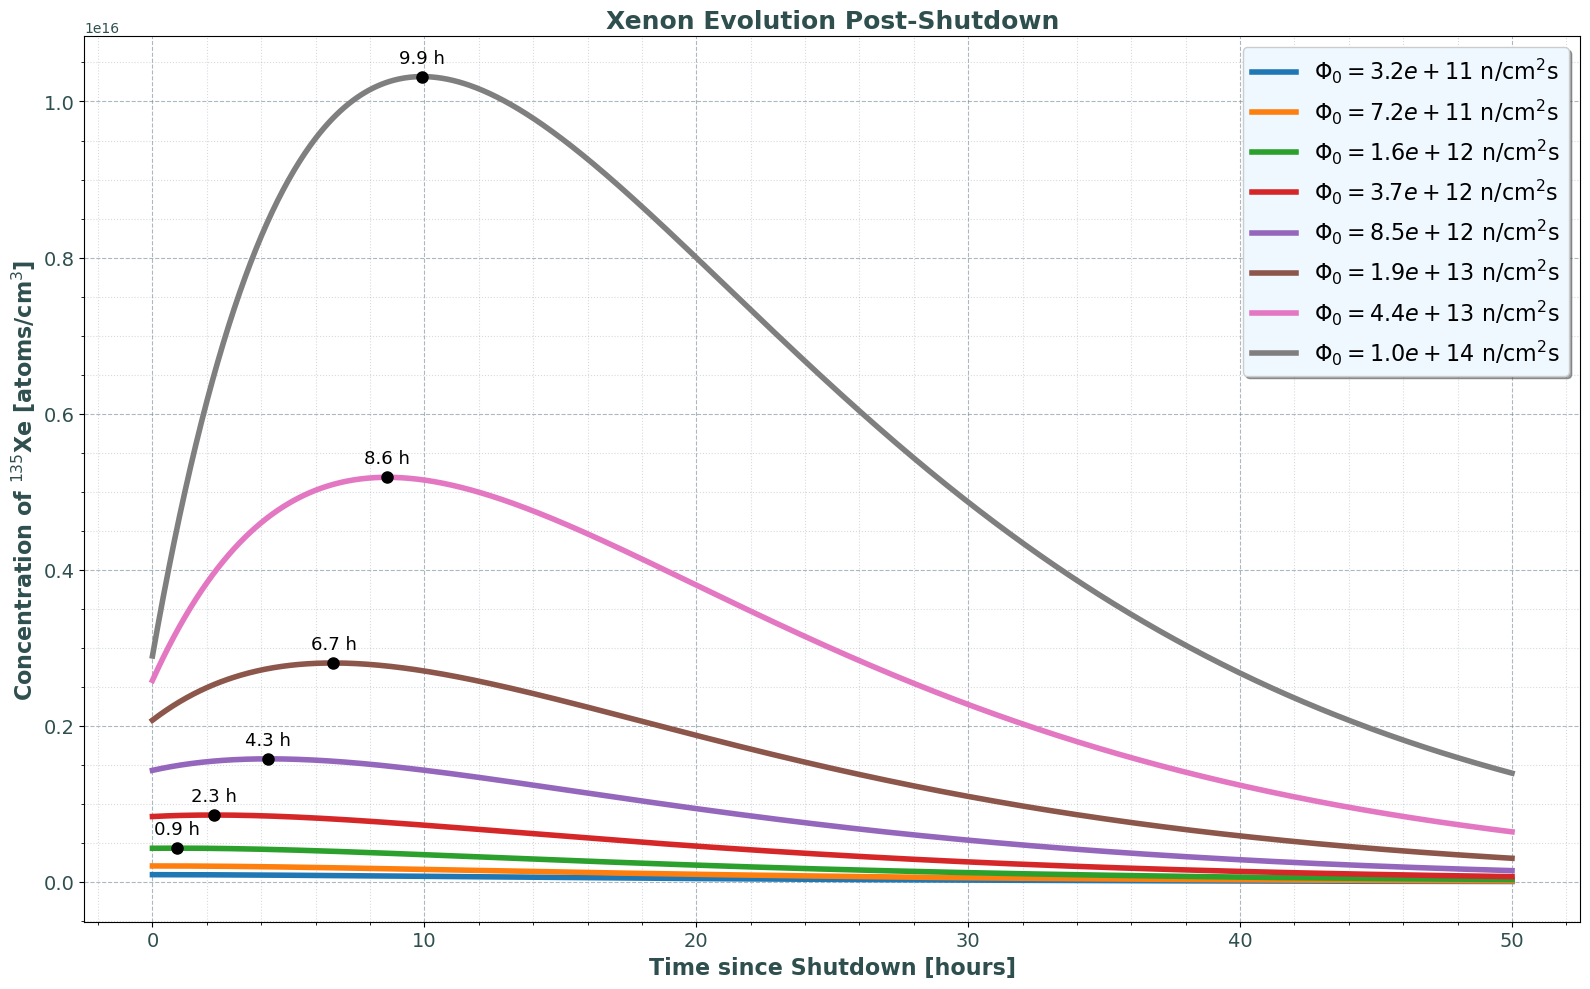

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def xenon_transient_analysis():
    # Parametri fisici
    gamma_I = 0.061
    gamma_Xe = 0.003
    lambda_I = 2.9e-5     # s^-1
    lambda_Xe = 2.1e-5    # s^-1
    sigma_a = 2.0e6 * 1e-24 # Sezione d'urto microscopica in cm^2 (2 milioni di barn)
    Sigma_f = 0.1         # Sezione d'urto macroscopica di fissione approssimata (cm^-1)
    
    # Array dei flussi da esplorare (da 10^10 a 10^14)
    fluxes = np.logspace(11.5, 14.0, 8)
    
    # Vettore temporale: 50 ore discretizzate
    t_hours = np.linspace(0, 50, 1000)
    t_seconds = t_hours * 3600
    
    # Setup del grafico unificato
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Iterazione sui flussi neutronici
    for phi in fluxes:
        # 1. Condizioni iniziali (Concentrazioni di equilibrio stazionario in atomi/cm^3)
        I_0 = (gamma_I * Sigma_f * phi) / lambda_I
        X_0 = ((gamma_I + gamma_Xe) * Sigma_f * phi) / (lambda_Xe + sigma_a * phi)
        
        # 2. Risoluzione analitica per X(t) a reattore spento (phi = 0)
        term1 = X_0 * np.exp(-lambda_Xe * t_seconds)
        term2 = (lambda_I * I_0) / (lambda_I - lambda_Xe) * (np.exp(-lambda_Xe * t_seconds) - np.exp(-lambda_I * t_seconds))
        X_t = term1 + term2
        
        # 3. Individuazione del picco
        peak_idx = np.argmax(X_t)
        t_peak_h = t_hours[peak_idx]
        X_peak = X_t[peak_idx]
        
        # Plot della curva
        line, = ax.plot(t_hours, X_t, lw=4, label=f"$\Phi_0 = {phi:.1e}$ n/cm$^2$s")
        
        # Mark del picco (Uso colore custom se richiesto per punti, #000000)
        if t_peak_h > 0.5: # Filtra picchi inesistenti (es. per flussi bassissimi)
            ax.plot(t_peak_h, X_peak, marker='o', markersize=8, color='#000000', zorder=5)
            ax.annotate(f"{t_peak_h:.1f} h", (t_peak_h, X_peak), 
                        textcoords="offset points", xytext=(0,10), ha='center', fontsize=13)

    # Formattazione Plot
    ax.set_title("Xenon Evolution Post-Shutdown", fontsize=18, fontweight='bold', color='#2F4F4F')
    ax.set_xlabel("Time since Shutdown [hours]", fontsize=16, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel("Concentration of $^{135}$Xe [atoms/cm$^3$]", fontsize=16, fontweight='bold', color='#2F4F4F')
    
    # Formattazione Tick (Major: 14, Minor: 12)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14, labelcolor='#2F4F4F')
    ax.tick_params(axis='both', which='minor', labelsize=12)
    
    # Griglie personalizzate
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda personalizzata (loc='best', fontsize=16)
    ax.legend(loc='best', frameon=True, shadow=True, fontsize=16, facecolor='#F0F8FF')

    #ax.set_ylim(0, 1e14)
    
    plt.tight_layout()
    plt.savefig("xenon_transient_analysis.png", dpi=300) # Salva il grafico ad alta risoluzione
    plt.show()

# Esecuzione
xenon_transient_analysis()

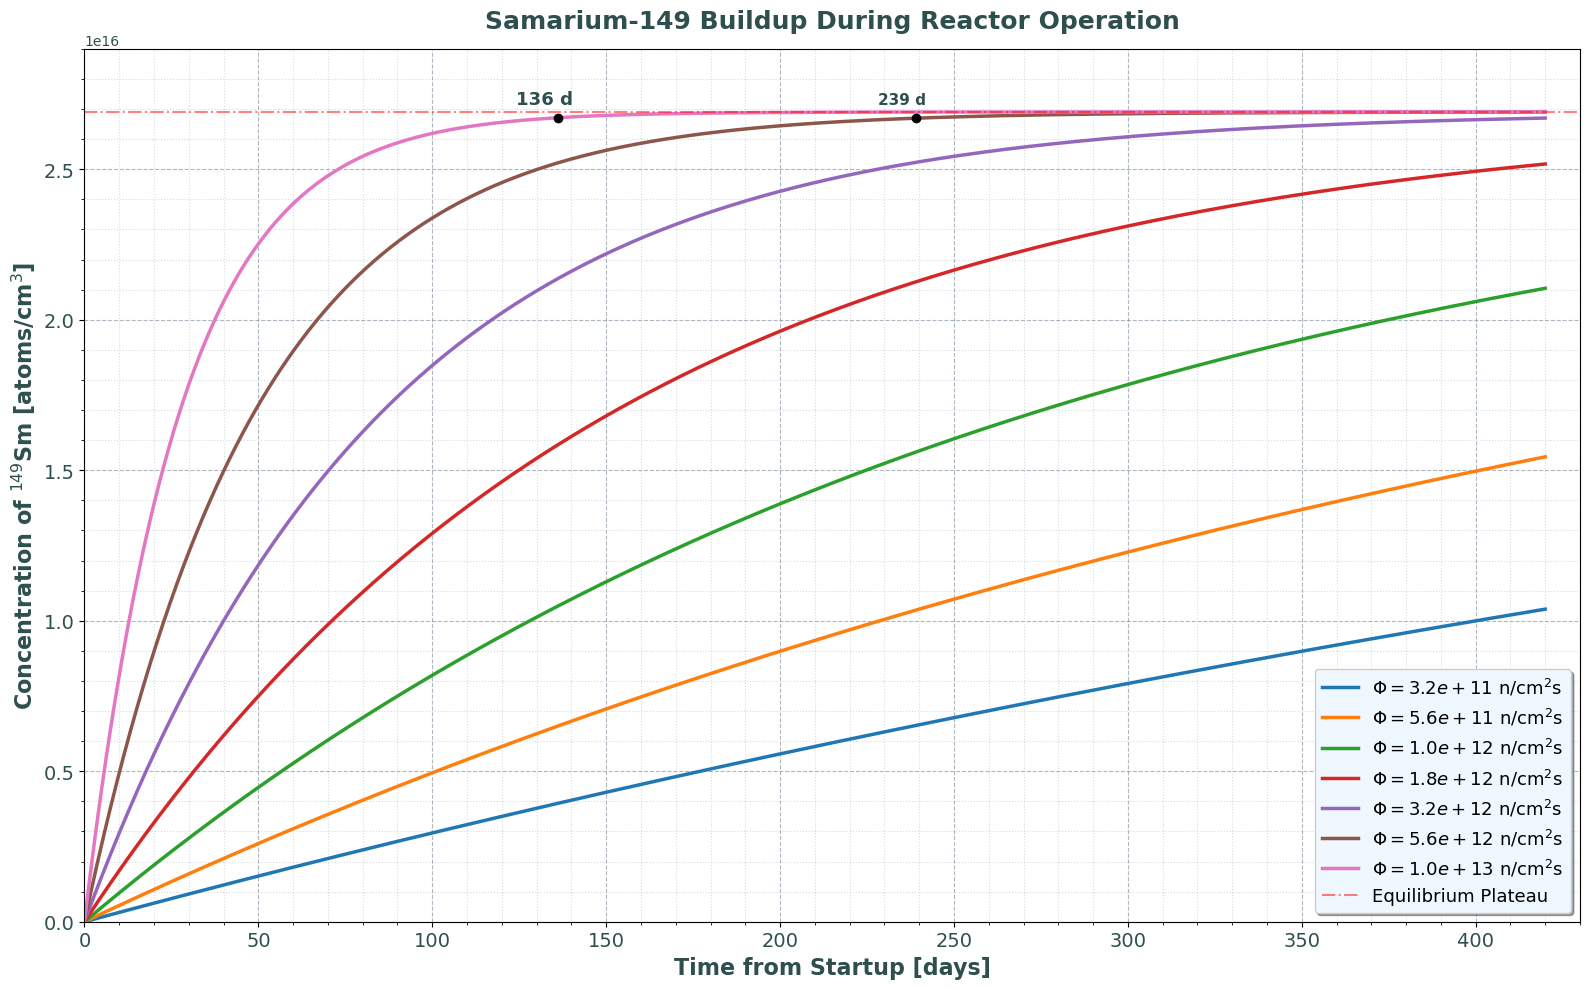

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_samarium_buildup_fixed():
    gamma_Pm = 0.0113        
    sigma_a_Sm = 4.2e4 * 1e-24  
    Sigma_f = 0.1            
    Sm_0 = (gamma_Pm * Sigma_f) / sigma_a_Sm
    
    fluxes = [3.2e11, 5.6e11, 1.0e12, 1.8e12, 3.2e12, 5.6e12, 1.0e13]
    
    t_days = np.linspace(0, 420, 2000)
    t_seconds = t_days * 24 * 3600
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    for phi in fluxes:
        Sm_t = Sm_0 * (1.0 - np.exp(-sigma_a_Sm * phi * t_seconds))
        ax.plot(t_days, Sm_t, lw=2.5, label=f"$\Phi = {phi:.1e}$ n/cm$^2$s")
        
        # Corrette le label da 'h' a 'd' (days) in accordo con l'asse X
        if phi == 1.0e13:  
            idx_136 = np.where(t_days >= 136)[0][0]
            ax.plot(t_days[idx_136], Sm_t[idx_136], marker='o', color='#000000', markersize=6, zorder=5)
            ax.annotate("136 d", (t_days[idx_136], Sm_t[idx_136]), textcoords="offset points", 
                        xytext=(-10, 10), ha='center', fontsize=13, fontweight='bold', color='#2F4F4F')
            
        elif phi == 5.6e12:  
            idx_239 = np.where(t_days >= 239)[0][0]
            ax.plot(t_days[idx_239], Sm_t[idx_239], marker='o', color='#000000', markersize=6, zorder=5)
            ax.annotate("239 d", (t_days[idx_239], Sm_t[idx_239]), textcoords="offset points", 
                        xytext=(-10, 10), ha='center', fontsize=11, fontweight='bold', color='#2F4F4F')

    ax.axhline(y=Sm_0, color='red', linestyle='-.', alpha=0.5, label='Equilibrium Plateau')
    
    ax.set_title("Samarium-149 Buildup During Reactor Operation", fontsize=18, fontweight='bold', color='#2F4F4F', pad=15)
    ax.set_xlabel("Time from Startup [days]", fontsize=16, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel("Concentration of $^{149}$Sm [atoms/cm$^3$]", fontsize=16, fontweight='bold', color='#2F4F4F')
    
    ax.set_xlim(0, 430)
    ax.set_ylim(0, 2.9e16)
    
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14, labelcolor='#2F4F4F')
    ax.tick_params(axis='both', which='minor', labelsize=12)
    
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='lower right', frameon=True, shadow=True, fontsize=13, facecolor='#F0F8FF')
    
    plt.tight_layout()
    plt.savefig("samarium_buildup_fixed.png", dpi=300)
    plt.show()

plot_samarium_buildup_fixed()

In [6]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. PARAMETRI FISICI E TEMPORALI
# =====================================================================

S_rate = 2.02e17 * 5.87905e-03   

time_steps_days = giorni_on + giorni_off

time_cumulative = np.insert(np.cumsum(time_steps_days), 0, 0.0)

# Costanti per la conversione
eV_to_Joule = 1.60218e-19
E_fission_approx_J = 200e6 * eV_to_Joule # 200 MeV in Joule
nu_medio_approx = 2.44 

# =====================================================================
# 2. ESTRAZIONE DATI DAI STATEPOINT
# =====================================================================

sp_files = glob.glob(os.path.join(PATH+"/", 'openmc_simulation_n*.h5'))
if not sp_files:
    raise FileNotFoundError(f"Nessun file 'openmc_simulation_n*.h5' trovato in {PATH}.")

sp_files = sorted(sp_files, key=lambda x: int(os.path.basename(x).split('_n')[1].split('.')[0]))

print(f"File trovati: {len(sp_files)} | Step temporali: {len(time_cumulative)}")

pot_kappa, pot_kappa_err = [], []
pot_nu, pot_nu_err = [], []
k_src_mean, k_src_std = [], []
k_bal_mean, k_bal_std = [], []

for i, sp_file in enumerate(sp_files):
    with openmc.StatePoint(sp_file) as sp:
        t_glob = sp.get_tally(name='fission_tot')
        
        # --- Kappa-Fission (Potenza Esatta) ---
        slice_k = t_glob.get_slice(scores=['kappa-fission'])
        k_val = slice_k.mean.flatten()[0]
        k_std = slice_k.std_dev.flatten()[0]
        
        # --- Nu-Fission (Potenza Stimata e k_src) ---
        slice_n = t_glob.get_slice(scores=['nu-fission'])
        n_val = slice_n.mean.flatten()[0]
        n_std = slice_n.std_dev.flatten()[0]
        
        # --- Altri score (absorption, leakage) ---
        slice_a = t_glob.get_slice(scores=['absorption'])
        a_val = slice_a.mean.flatten()[0]
        a_std = slice_a.std_dev.flatten()[0]
        
        t_leak = sp.get_tally(name='leakage_tot')
        l_val = t_leak.mean.sum()
        l_std = np.sqrt(np.sum(t_leak.std_dev**2))
        
        # --- LOGICA CORRETTA PER LA POTENZA ---
        if i < len(giorni_on):
            curr_S = S_rate
        else:
            curr_S = 0.0  # Forza a zero la potenza nella fase OFF
        
        # 1. Calcolo Potenze [W]
        pot_kappa.append(k_val * curr_S * eV_to_Joule)
        pot_kappa_err.append(k_std * curr_S * eV_to_Joule)
        
        pot_nu.append((n_val / nu_medio_approx) * curr_S * E_fission_approx_J)
        pot_nu_err.append((n_std / nu_medio_approx) * curr_S * E_fission_approx_J)
        
        # 2. Calcolo Moltiplicazioni (k_src e k_bal)
        ks_val = n_val / (1.0 + n_val)
        ks_std = n_std / (1.0 + n_val)**2
        k_src_mean.append(ks_val)
        k_src_std.append(ks_std)
        
        losses = a_val + l_val
        kb_val = n_val / losses
        kb_std = kb_val * np.sqrt((n_std/n_val)**2 + (np.sqrt(a_std**2 + l_std**2)/losses)**2)
        k_bal_mean.append(kb_val)
        k_bal_std.append(kb_std)

# Conversione in array
pot_kappa, pot_kappa_err = np.array(pot_kappa), np.array(pot_kappa_err)
pot_nu, pot_nu_err = np.array(pot_nu), np.array(pot_nu_err)
k_src_mean, k_src_std = np.array(k_src_mean), np.array(k_src_std)
k_bal_mean, k_bal_std = np.array(k_bal_mean), np.array(k_bal_std)

# Verifica strutturale prima del plot
assert len(time_cumulative) == len(pot_kappa), f"Mismatch temporale: {len(time_cumulative)} tempi vs {len(pot_kappa)} potenze."
assert len(time_cumulative) == len(k_src_mean), f"Mismatch temporale: {len(time_cumulative)} tempi vs {len(k_src_mean)} k_src."

# =====================================================================
# 3. PLOTTING
# =====================================================================

def apply_style(ax, title, ylabel):
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel("Time [days]", fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')



File trovati: 19 | Step temporali: 19


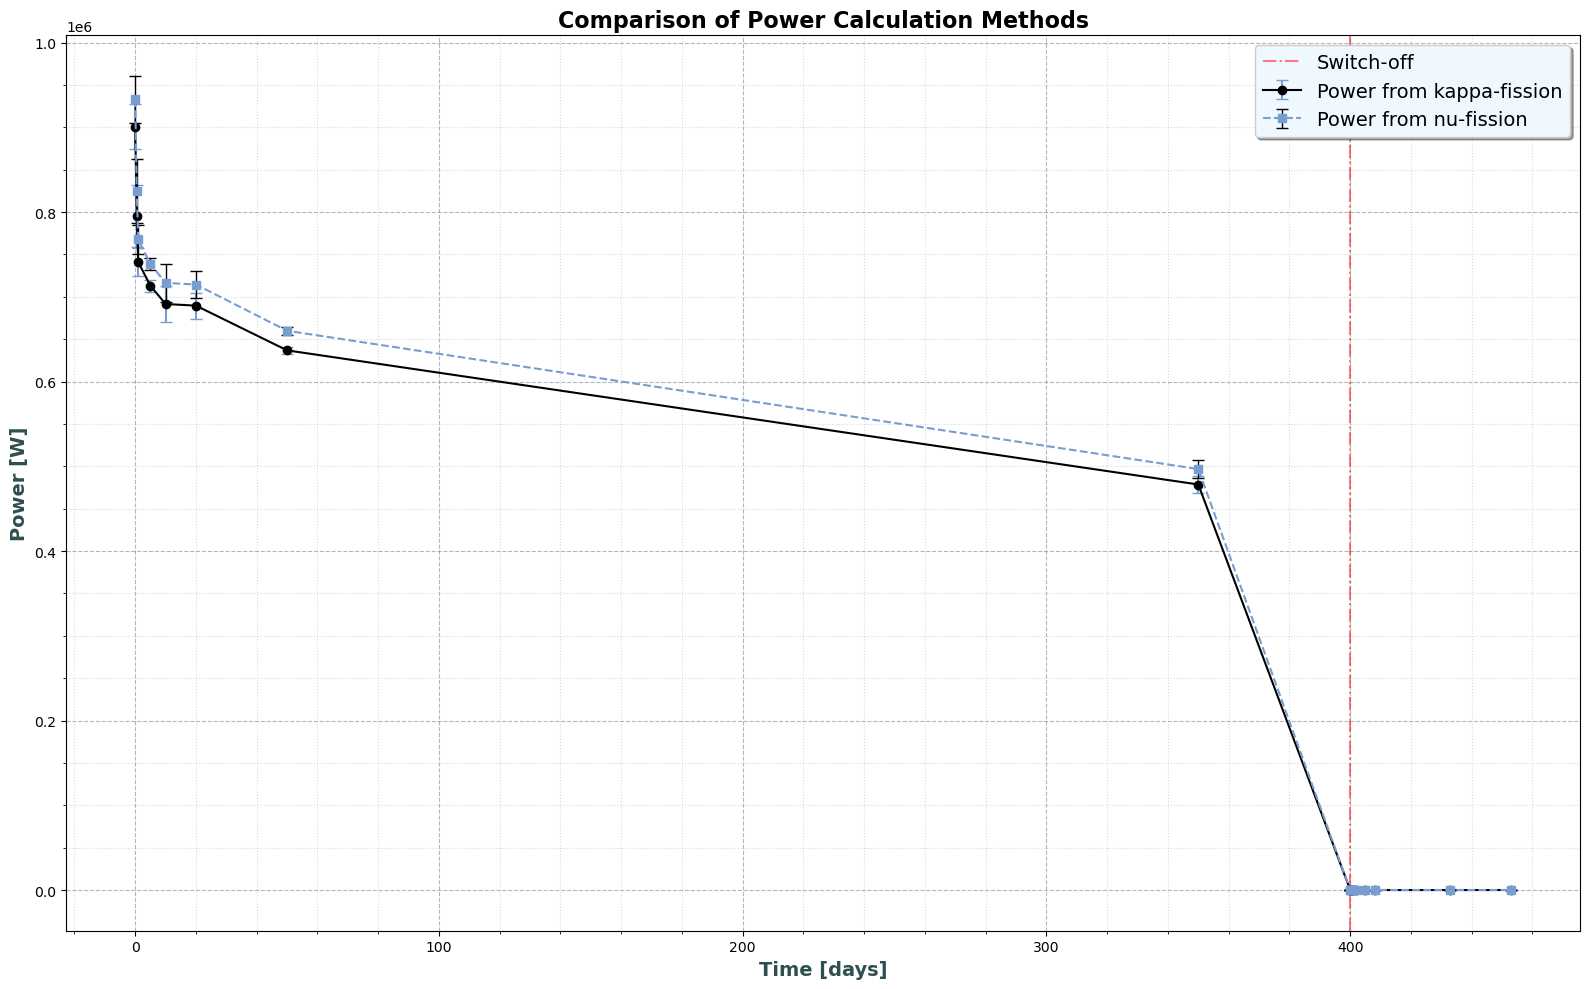

In [7]:
# --- PLOT 1: Confronto Potenze ---
fig1, ax1 = plt.subplots(figsize=(16, 10))
ax1.errorbar(time_cumulative, pot_kappa, yerr=pot_kappa_err, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, elinewidth=1.5,
             label='Power from kappa-fission')
ax1.errorbar(time_cumulative, pot_nu, yerr=pot_nu_err, 
             fmt='s--', color='#789DD1', ecolor='#000000', capsize=4, elinewidth=1,
             label='Power from nu-fission')

ax1.axvline(x=sum(giorni_on), color='red', linestyle='-.', alpha=0.5, label='Switch-off')
apply_style(ax1, "Comparison of Power Calculation Methods", "Power [W]")
plt.tight_layout()
plt.show()

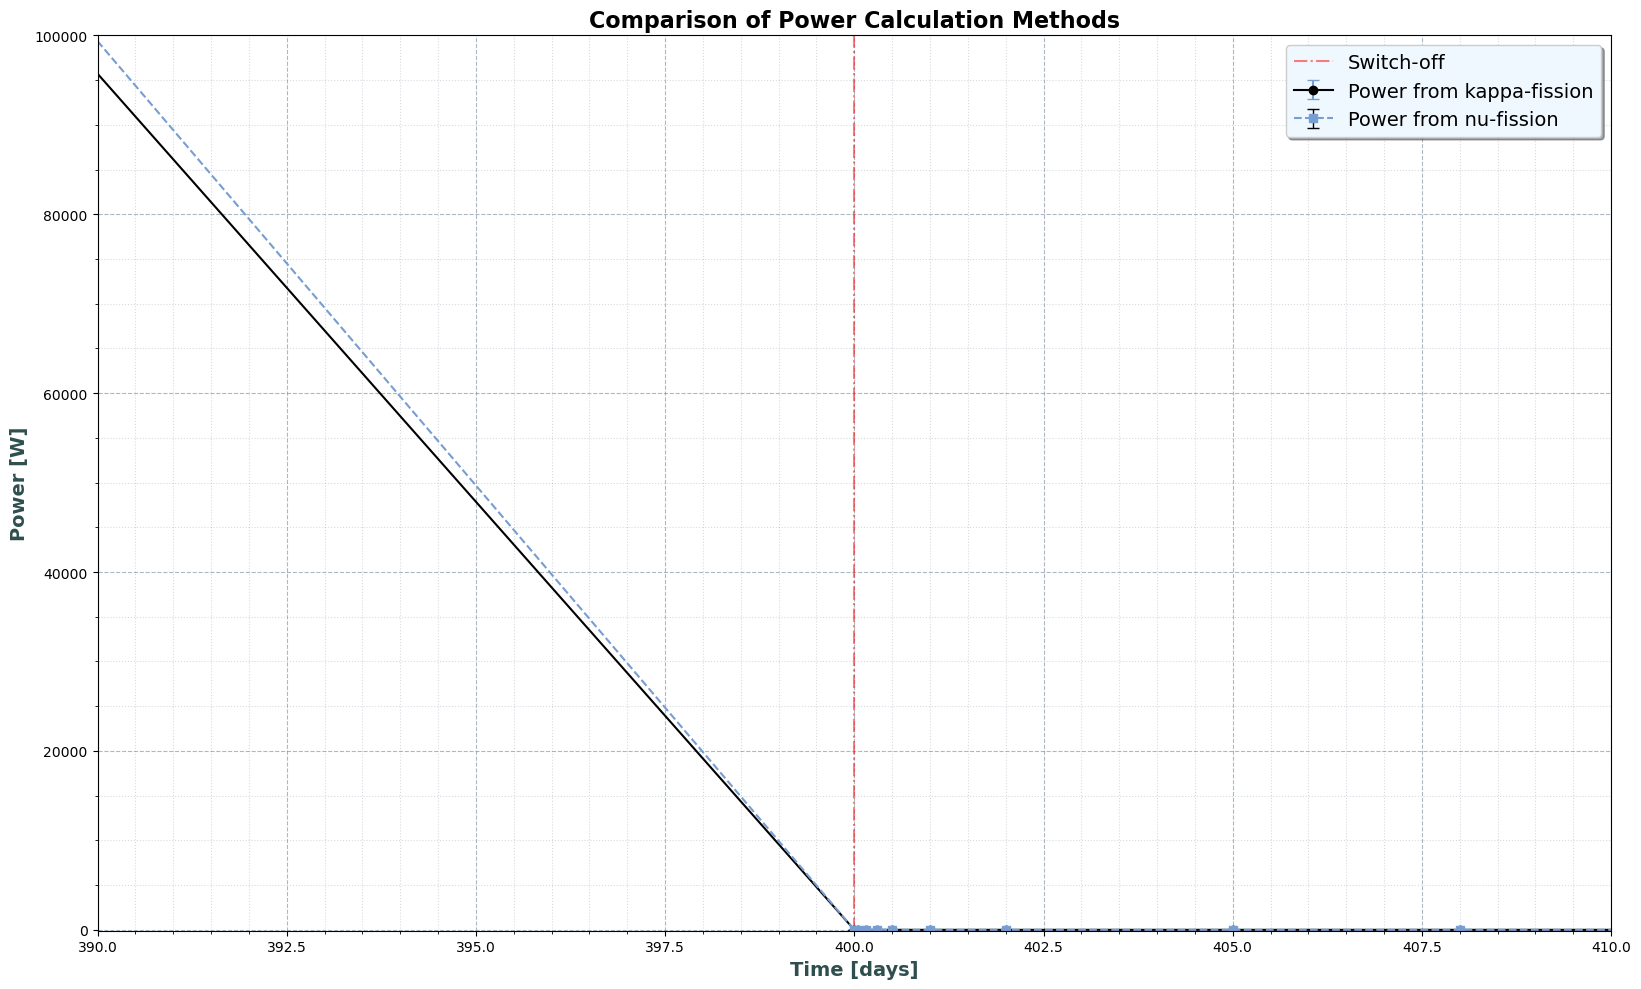

In [8]:
# --- PLOT 1: Confronto Potenze ---
fig1, ax1 = plt.subplots(figsize=(16, 10))
ax1.errorbar(time_cumulative, pot_kappa, yerr=pot_kappa_err, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, elinewidth=1.5,
             label='Power from kappa-fission')
ax1.errorbar(time_cumulative, pot_nu, yerr=pot_nu_err, 
             fmt='s--', color='#789DD1', ecolor='#000000', capsize=4, elinewidth=1,
             label='Power from nu-fission')

ax1.axvline(x=sum(giorni_on), color='red', linestyle='-.', alpha=0.5, label='Switch-off')
apply_style(ax1, "Comparison of Power Calculation Methods", "Power [W]")
plt.tight_layout()
ax1.set_xlim(390 , 410)
ax1.set_ylim(-100, 0.1e6)
plt.show()

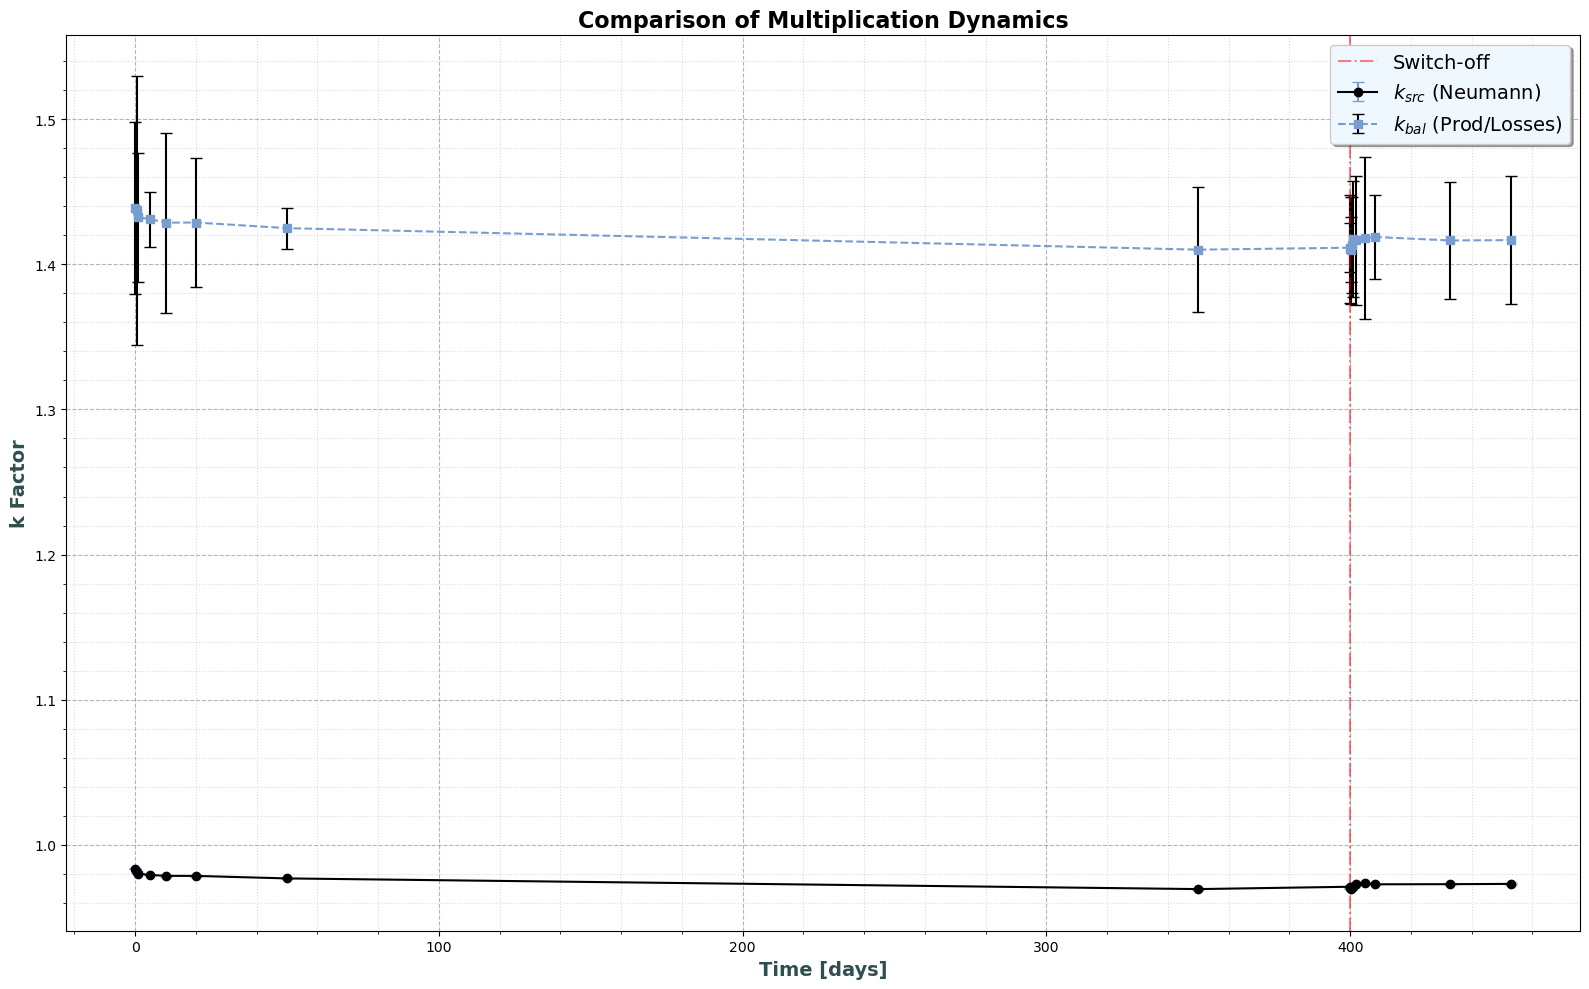

In [9]:
# --- PLOT 2: Confronto Moltiplicazioni ---
fig2, ax2 = plt.subplots(figsize=(16, 10))
ax2.errorbar(time_cumulative, k_src_mean, yerr=k_src_std, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, 
             label=r'$k_{src}$ (Neumann)')
ax2.errorbar(time_cumulative, k_bal_mean, yerr=k_bal_std, 
             fmt='s--', color='#789DD1', ecolor='#000000', capsize=4, 
             label=r'$k_{bal}$ (Prod/Losses)')

ax2.axvline(x=spegnimento, color='red', linestyle='-.', alpha=0.5, label='Switch-off')
apply_style(ax2, "Comparison of Multiplication Dynamics", "k Factor")
plt.tight_layout()

plt.show()

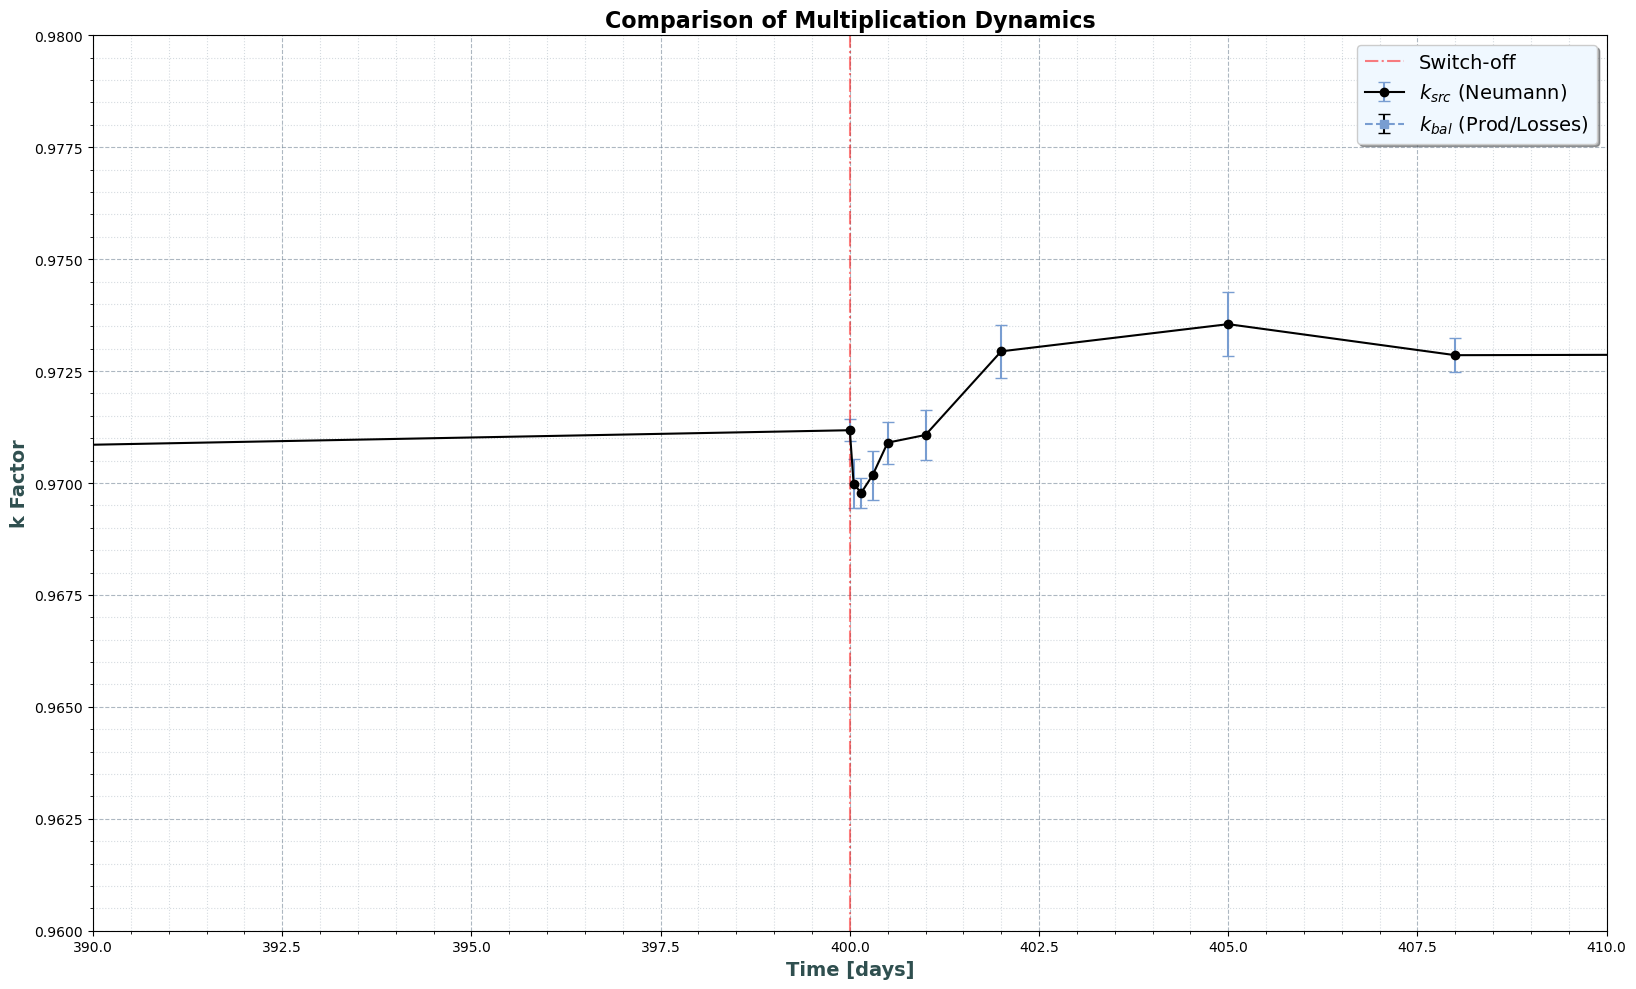

In [10]:
fig2, ax2 = plt.subplots(figsize=(16, 10))
ax2.errorbar(time_cumulative, k_src_mean, yerr=k_src_std, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, 
             label=r'$k_{src}$ (Neumann)')
ax2.errorbar(time_cumulative, k_bal_mean, yerr=k_bal_std, 
             fmt='s--', color='#789DD1', ecolor='#000000', capsize=4, 
             label=r'$k_{bal}$ (Prod/Losses)')

ax2.axvline(x=spegnimento, color='red', linestyle='-.', alpha=0.5, label='Switch-off')
apply_style(ax2, "Comparison of Multiplication Dynamics", "k Factor")
plt.tight_layout()
ax2.set_xlim(390 , 410)
ax2.set_ylim(0.96 , 0.98)
plt.show()

La risposta breve è che stiamo calcolando due grandezze fisiche diverse: il $k_{src}$ (moltiplicazione della sorgente) e il $k_{eff}$ (autovalore fondamentale).Ecco la derivazione rigorosa e le differenze.1. La derivazione di $k = \nu / (1+\nu)$In una simulazione fixed source, lo score nu-fission (chiamiamolo $P_\nu$) restituisce il numero totale di neutroni di fissione creati per ogni singolo neutrone di sorgente primario, integrato su tutte le generazioni.Fisicamente, ogni generazione neutronica è moltiplicata per un fattore $k_{src}$:Neutroni di sorgente: $1$Fissioni di 1° generazione: $k_{src}$Fissioni di 2° generazione: $k_{src}^2$Fissioni di $i$-esima generazione: $k_{src}^i$Lo score totale $P_\nu$ è la somma di questa serie geometrica (che converge poiché il sistema è sottocritico, $k_{src} < 1$):$$P_\nu = \sum_{i=1}^{\infty} k_{src}^i = \frac{k_{src}}{1 - k_{src}}$$Risolvendo per $k_{src}$ otteniamo esattamente la formula che abbiamo usato:$$k_{src} = \frac{P_\nu}{1 + P_\nu}$$2. Il calcolo tramite $\nu / \Sigma_a$ (Bilancio Neutronico)Quando suggerisci di usare il rapporto con l'assorbimento, stai invocando la definizione classica di $k_{eff}$ basata sul bilancio integrale tra produzione e perdite:$$k = \frac{\text{Produzione}}{\text{Assorbimento} + \text{Fughe}} = \frac{\int \nu\Sigma_f \phi dV}{\int \Sigma_a \phi dV + J_{out}}$$In OpenMC, potresti calcolare questo valore estraendo tre Tally globali:$$k_{bal} = \frac{\text{Tally(nu-fission)}}{\text{Tally(absorption)} + \text{Tally(leakage)}}$$Nota: se ignori le fughe (leakage) e fai solo nu-fission / absorption, stai calcolando il $k_{\infty}$, che sovrastima drasticamente il valore in un reattore di dimensioni finite.3. Cosa cambia? (Differenza Fisica)Sebbene siano spesso vicini numericamente, $k_{src}$ e $k_{eff}$ non sono la stessa cosa.$k_{eff}$ (Autovalore): È una proprietà intrinseca del nocciolo (geometria e materiali). Dipende dalla distribuzione spaziale del flusso nel suo modo fondamentale asintotico.$k_{src}$ (Moltiplicazione Sorgente): Dipende fortemente dall'importanza spaziale ed energetica della sorgente. Se metti la sorgente esatta al centro del nocciolo (dove l'importanza neutronica è massima), i neutroni primari causeranno molte fissioni prima di fuggire. In questo caso $k_{src} > k_{eff}$. Se metti la sorgente vicino al riflettore, la maggior parte dei neutroni sfuggirà subito e $k_{src} < k_{eff}$.Sono proporzionali? Sì, seguono lo stesso trend (se avveleni il nocciolo con lo Xeno, scendono entrambi). Ma il rapporto $k_{src} / k_{eff}$ (spesso chiamato parametro $\varphi^*$ o importanza della sorgente) non è costante e varia al variare del burnup o del posizionamento della sorgente.4. Quale è meglio?Per un reattore critico standard, esiste solo $k_{eff}$.Per il tuo sistema (ADS guidato da sorgente), $k_{src}$ è il parametro fisicamente più corretto e utile.È il $k_{src}$ (non il $k_{eff}$) che determina l'amplificazione reale della potenza della tua macchina. La potenza totale del tuo reattore dipende direttamente da quanto quella specifica sorgente riesce a moltiplicare, seguendo la legge:$$P_{tot} \propto S \cdot \frac{1}{1 - k_{src}}$$Usare $k = \nu / (1+\nu)$ estratto da nu-fission è computazionalmente più rapido (richiede una sola tally invece di tre) ed è l'esatto indicatore delle prestazioni della tua configurazione sorgente-target.

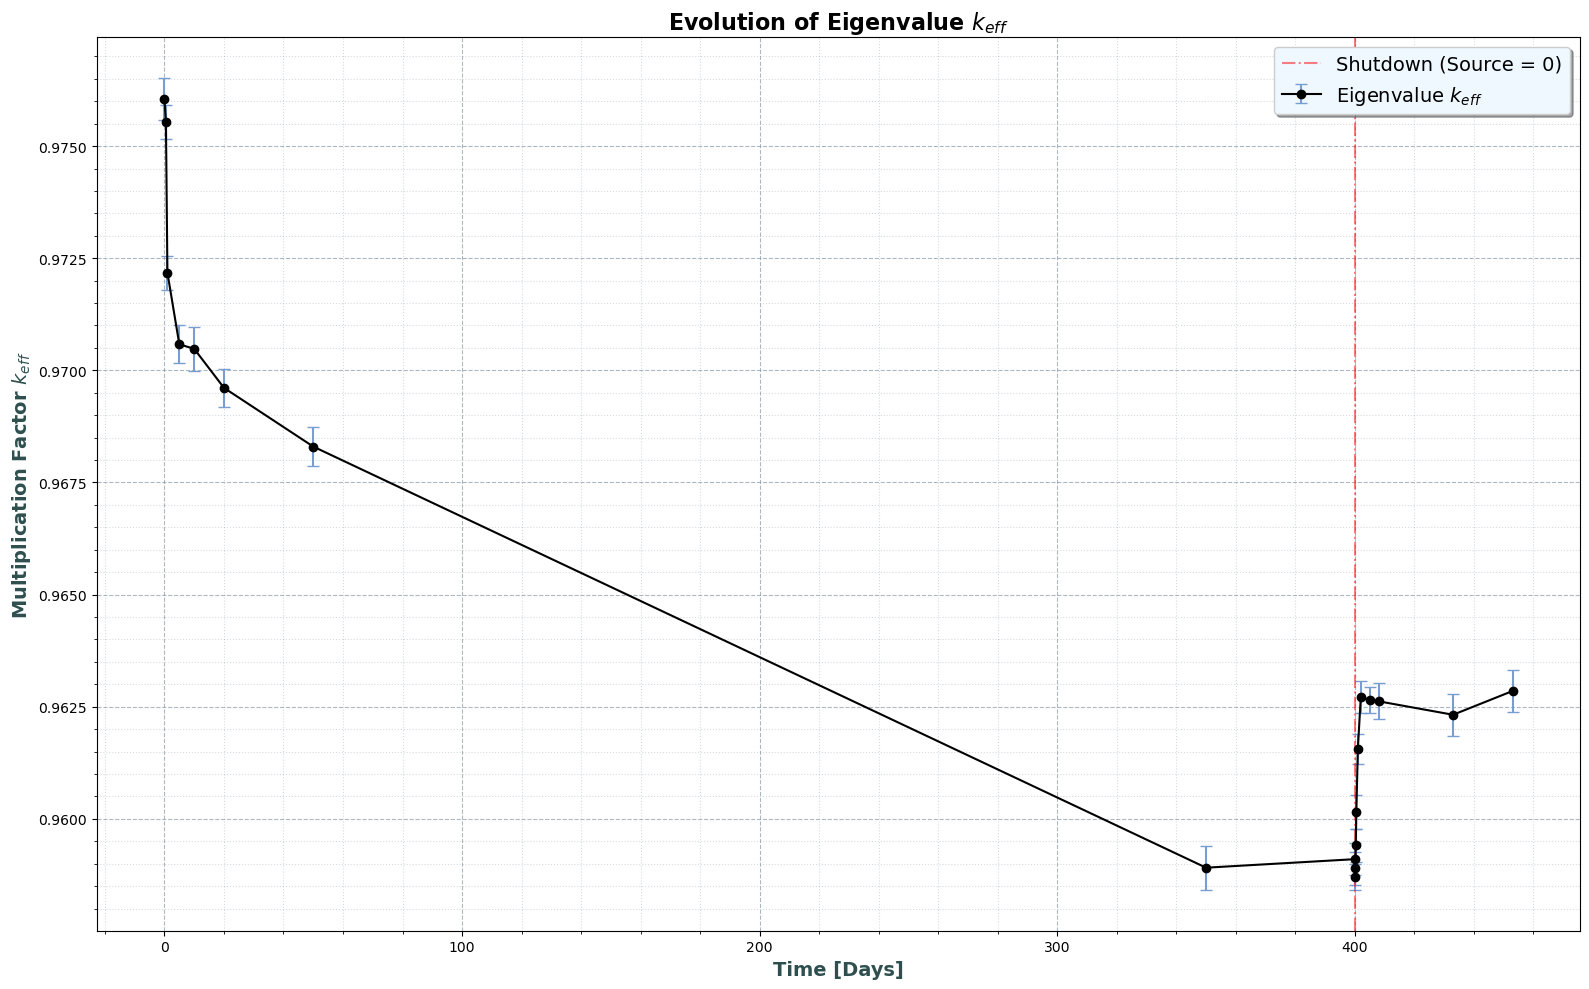

In [17]:
# =====================================================================
# 5. ANALISI TRANSITORIO AUTOVALORE K_EFF (Da post-processing)
# =====================================================================


PITCH = PATH.replace("depletion_", "") 

file_k_transitorio = os.path.join(PATH, f"k_eff_transitorio_{PITCH}.txt")

tempi_k_eff = []
k_eff_vals = []
k_eff_errs = []

# Lettura sicura del file (ignora le righe di testo/header)
if os.path.exists(file_k_transitorio):
    with open(file_k_transitorio, "r") as f:
        for line in f.readlines():
            parts = line.split()
            # Cerca solo le righe con 4 elementi numerici (Step, Tempo, K, Err)
            if len(parts) >= 4:
                try:
                    t = float(parts[1])
                    k = float(parts[2])
                    err = float(parts[3])
                    tempi_k_eff.append(t)
                    k_eff_vals.append(k)
                    k_eff_errs.append(err)
                except ValueError:
                    pass # Salta la riga se non è convertibile in float (es. Header)
                    
    tempi_k_eff = np.array(tempi_k_eff)
    k_eff_vals = np.array(k_eff_vals)
    k_eff_errs = np.array(k_eff_errs)
    
    # -----------------------------------------------------------------
    # PLOTTING
    # -----------------------------------------------------------------
    fig5, ax5 = plt.subplots(figsize=(16, 10))
    
    ax5.errorbar(tempi_k_eff, k_eff_vals, yerr=k_eff_errs, 
                 fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, elinewidth=1.5,
                 label=r'Eigenvalue $k_{eff}$')
    
    ax5.axvline(x=spegnimento, color='red', linestyle='-.', alpha=0.5, label='Shutdown (Source = 0)')
    
    # Stile coerente con il resto del notebook
    ax5.set_title("Evolution of Eigenvalue $k_{eff}$", fontsize=16, fontweight='bold')
    ax5.set_xlabel("Time [Days]", fontsize=14, fontweight='bold', color='#2F4F4F')
    ax5.set_ylabel("Multiplication Factor $k_{eff}$", fontsize=14, fontweight='bold', color='#2F4F4F')

    #ax5.axvline(x=spegnimento, color='red', linestyle='-.', alpha=0.5, label='Shutdown')
    #ax5.axvline(x=spegnimento + 15, color='blue', linestyle='-.', alpha=0.5, label='Post-Shutdown Peak')
    
    ax5.minorticks_on()
    ax5.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax5.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax5.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')
    
    plt.tight_layout()
    plt.show()

else:
    print(f"File '{file_k_transitorio}' non trovato. ")

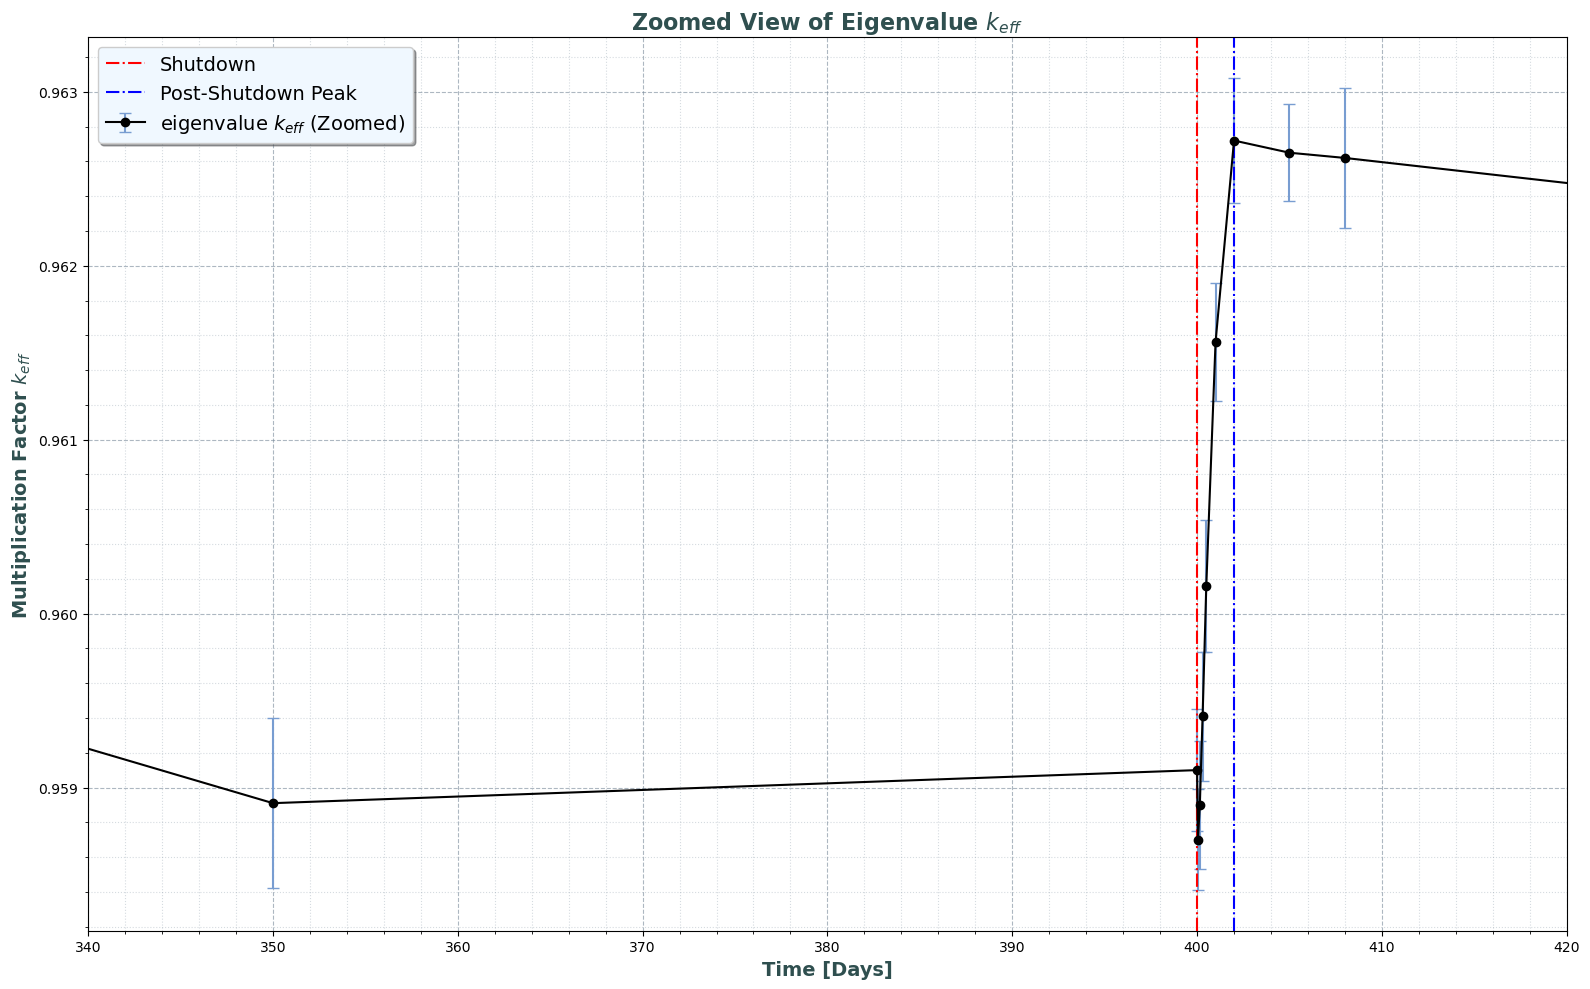

In [23]:
# -----------------------------------------------------------------
# PLOTTING DETTAGLIO TRANSITORIO (ZOOM 395-410 GIORNI)
# -----------------------------------------------------------------

# Maschera booleana per l'intervallo temporale richiesto
mask_zoom = (tempi_k_eff >= 340) & (tempi_k_eff <= 420)

if np.any(mask_zoom):
    # Isolamento dei dati nell'intervallo per il calcolo dei limiti Y
    k_zoom = k_eff_vals[mask_zoom]
    err_zoom = k_eff_errs[mask_zoom]
    
    # Calcolo dei limiti dinamici per l'asse Y includendo le barre d'errore e un 5% di padding
    y_min = np.min(k_zoom - err_zoom)
    y_max = np.max(k_zoom + err_zoom)
    padding = (y_max - y_min) * 0.05
    
    fig6, ax6 = plt.subplots(figsize=(16, 10))
    
    # Plot con barre d'errore
    ax6.errorbar(tempi_k_eff, k_eff_vals, yerr=k_eff_errs, 
                 fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, elinewidth=1.5,
                 label=r'eigenvalue $k_{eff}$ (Zoomed)')
    
    # Limiti degli assi ottimizzati
    ax6.set_xlim(340, 420)
    ax6.set_ylim(y_min - padding, y_max + padding)
    
    # Linee verticali di benchmark (Spegnimento e picco)
    if 'spegnimento' in locals() or 'spegnimento' in globals():
        ax6.axvline(x=spegnimento, color='red', linestyle='-.', label='Shutdown')
        ax6.axvline(x=spegnimento + 2, color='blue', linestyle='-.', label='Post-Shutdown Peak')
    elif 't_off_start' in locals() or 't_off_start' in globals():
        ax6.axvline(x=spegnimento, color='red', linestyle='-.', label='Shutdown (Source = 0)')
    

    #ax6.axvline(x=spegnimento + 0.3, color='orange', linestyle='-.', label='Xenon peak')
    # Stile ed etichette
    ax6.set_title("Zoomed View of Eigenvalue $k_{eff}$", fontsize=16, fontweight='bold', color='#2F4F4F')
    ax6.set_xlabel("Time [Days]", fontsize=14, fontweight='bold', color='#2F4F4F')
    ax6.set_ylabel("Multiplication Factor $k_{eff}$", fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # Griglia e Legenda in stile scientifico richiesto
    ax6.minorticks_on()
    ax6.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax6.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax6.legend(loc='best', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')
    
    plt.tight_layout()
    plt.savefig('k_eff_transitorio_zoom.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Attenzione: Nessun dato presente nell'intervallo 395-410 giorni per questa simulazione.")

In [21]:
# =====================================================================
# 6. CALCOLO DEL DELTA RHO POST-SPEGNIMENTO (Xenon Decay)
# =====================================================================

# 1. Identificazione dell'istante esatto di spegnimento (t = 200 giorni)
# Usiamo np.isclose per evitare problemi di precisione floating-point
idx_shutdown = np.where(np.isclose(tempi_k_eff, spegnimento))[0]

if len(idx_shutdown) == 0:
    print("Errore: Impossibile trovare il tempo esatto di spegniemnto nell'array.")
else:
    # Estrazione valori al momento dello shutdown
    idx_shut = idx_shutdown[0]
    k_shut = k_eff_vals[idx_shut]
    err_shut = k_eff_errs[idx_shut]

    # 2. Isolamento della fase OFF (tempi strettamente maggiori di 200 giorni)
    mask_off = (tempi_k_eff > spegnimento) & (tempi_k_eff < 415)
    tempi_off = tempi_k_eff[mask_off]
    k_off = k_eff_vals[mask_off]
    err_off = k_eff_errs[mask_off]

    # 3. Ricerca del valore massimo di k nella fase OFF
    idx_max_off = np.argmax(k_off)
    k_max = k_off[idx_max_off]
    err_max = err_off[idx_max_off]
    t_max = tempi_off[idx_max_off]

    k_ideale = 0.97547
    delta = k_max - k_shut
    # 4. Calcolo Delta Rho in pcm
    delta_rho_pcm = (delta / (k_ideale * (k_ideale + delta))) * 1e5

    # 5. Propagazione dell'errore in quadratura
    err_delta_rho_pcm = 1e5 * np.sqrt((err_shut / k_shut**2)**2 + (err_max / k_max**2)**2)

    # 6. Stampa Scientifica
    print("=" * 60)
    print("ANALISI REATTIVITA' POST-SPEGNIMENTO (Decadimento Xeno)")
    print("=" * 60)
    print(f"Stato a Spegnimento (t = {spegnimento} gg):")
    print(f"  k_eff = {k_shut:.5f} +/- {err_shut:.5f}")
    print("-" * 60)
    print(f"Stato di Massima Reattività (t = {t_max:.2f} gg):")
    print(f"  k_eff = {k_max:.5f} +/- {err_max:.5f}")
    print("-" * 60)
    print(f"Delta Reattività Inserita RISCALATA (Δρ):")
    print(f"  Δρ = {delta_rho_pcm:.1f} +/- {err_delta_rho_pcm:.1f} pcm")
    print("=" * 60)

ANALISI REATTIVITA' POST-SPEGNIMENTO (Decadimento Xeno)
Stato a Spegnimento (t = 400.0 gg):
  k_eff = 0.95910 +/- 0.00035
------------------------------------------------------------
Stato di Massima Reattività (t = 402.00 gg):
  k_eff = 0.96272 +/- 0.00036
------------------------------------------------------------
Delta Reattività Inserita RISCALATA (Δρ):
  Δρ = 368.4 +/- 54.4 pcm
